In [4]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

nltk.download('vader_lexicon')

df = pd.read_csv("spotify_millsongdata.csv")

additional_df = pd.read_csv("additional_features.csv")

vds = SentimentIntensityAnalyzer()

records = []
for _, row in df.iterrows():
    scores = vds.polarity_scores(str(row["text"]))
    records.append({
        "Song":     row["song"],
        "Artist":   row["artist"],
        "Compound": scores["compound"],
        "Negative":      scores["neg"],
        "Neutral":      scores["neu"],
        "Positive":      scores["pos"],
    })

sentiment_df = pd.DataFrame(records)

merged_df = pd.merge(sentiment_df, additional_df, how="inner", left_on="Song", right_on="track_name")

# Drop duplicate song name column if needed
merged_df.drop(columns=["Unnamed: 0", "track_id", "duration_ms", "time_signature", "track_name", "artists", "album_name"], inplace=True)
merged_df = merged_df.drop_duplicates(subset=['Song'], keep='first')

# Save merged dataset to CSV
merged_df.to_csv("merged_spotify_dataset.csv", index=False)

print("Merged dataset saved as 'merged_spotify_dataset.csv'")

print(merged_df.columns)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/shayna/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Merged dataset saved as 'merged_spotify_dataset.csv'
Index(['Song', 'Artist', 'Compound', 'Negative', 'Neutral', 'Positive',
       'popularity', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'track_genre'],
      dtype='object')


In [12]:
import torch
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

merged_df = pd.read_csv("merged_spotify_dataset.csv") 

#initialize embedder and regressor
device    = "cuda" if torch.cuda.is_available() else "cpu"
embedder  = SentenceTransformer("BAAI/bge-large-en-v1.5", device=device)
regressor = Ridge()

#build text descriptions for each track
def row_to_description(row):
    return (f"A {row['track_genre']} song called '{row['Song']}' by {row['Artist']} "
            f"that is {'explicit' if row['explicit'] else 'not explicit'}, "
            f"with popularity {row['popularity']:.0f}, "
            f"{'high' if row['energy']>0.6 else 'low'} energy, "
            f"and {'high' if row['acousticness']>0.6 else 'low'} acousticness.")

descriptions = merged_df.apply(row_to_description, axis=1).tolist()

#compute embeddings for all tracks (only once)
X_embeddings = embedder.encode(
    descriptions,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

#train a Ridge regressor on true Spotify features
feature_cols = [
    'Compound','Negative','Neutral','Positive',
    'danceability','energy','key','loudness',
    'mode','speechiness','acousticness',
    'instrumentalness','liveness','valence','tempo'
]
y = merged_df[feature_cols].values

X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y, test_size=0.2, random_state=42
)
regressor.fit(X_train, y_train)
print(f"R² on test set: {regressor.score(X_test, y_test):.3f}")

#kmeans on embeddings
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42).fit(X_embeddings)

#process a new user query end-to-end
def process_user_query(query_text, k=10):
    q_emb = embedder.encode([query_text], convert_to_numpy=True, normalize_embeddings=True)
    pred_feats = regressor.predict(q_emb)[0]
    feat_dict = dict(zip(feature_cols, pred_feats))
    print("Predicted features:", feat_dict)
    cluster_label = kmeans.predict(q_emb)[0]
    print("Assigned cluster:", cluster_label)
    cluster_idxs = np.where(kmeans.labels_ == cluster_label)[0]
    dists = np.linalg.norm(X_embeddings[cluster_idxs] - q_emb, axis=1)
    nearest = cluster_idxs[np.argsort(dists)[:k]]
    results = merged_df.iloc[nearest][['Song','Artist']].reset_index(drop=True)
    print(f"Top {k} nearest songs:")
    display(results)

Batches: 100%|██████████| 87/87 [01:44<00:00,  1.20s/it]


R² on test set: 0.236


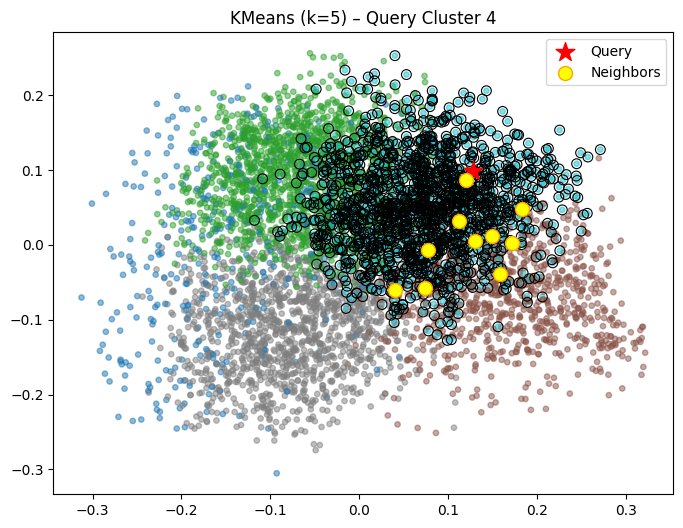

Top neighbors:
                                 Song           Artist
0          Can't Help Falling In Love        Bob Dylan
1                     Falling In Love        Aerosmith
2                           You And I    One Direction
3                         Heavy Heart            Heart
4                                Love    Cliff Richard
5  I Heard The Bells On Christmas Day      Carly Simon
6               Make You Feel My Love     Neil Diamond
7                             Fix You         Coldplay
8                          I Like You  Christina Perri
9                I Won't Let You Down         Westlife


In [14]:
#dynamic query processing

import numpy as np
from sentence_transformers import SentenceTransformer

def process_user_query(query_text, k=10):
    query_emb = embedder.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    
    pred_feats = regressor.predict(query_emb)[0]
    print("Predicted feature vector:")
    for name, val in zip(feature_cols, pred_feats):
        print(f"  {name}: {val:.3f}")
    
    cluster_label = kmeans.predict(query_emb)[0]
    print(f"\nAssigned to cluster: {cluster_label}")
    
    cluster_idxs = np.where(kmeans.labels_ == cluster_label)[0]
    dists = np.linalg.norm(X_embeddings[cluster_idxs] - query_emb, axis=1)
    nearest = cluster_idxs[np.argsort(dists)[:k]]
    neighbors = merged_df.iloc[nearest][['Song','Artist']].reset_index(drop=True)
    
    print(f"\nTop {k} nearest songs in the same cluster:")
    print(neighbors)

while True:
    q = input("Describe the kind of music you're in the mood for: (enter 'quit' to exit)")
    if q.lower() == 'quit':
        break
    process_user_query(q, k=10)


Predicted feature vector:
  Compound: 0.528
  Negative: 0.069
  Neutral: 0.777
  Positive: 0.154
  danceability: 0.632
  energy: 0.319
  key: 6.894
  loudness: -18.049
  mode: 0.636
  speechiness: 0.060
  acousticness: 0.761
  instrumentalness: 0.424
  liveness: 0.191
  valence: 0.395
  tempo: 91.461

Assigned to cluster: 4

Top 10 nearest songs in the same cluster:
                    Song                     Artist
0                  Relax  Frankie Goes To Hollywood
1            I Feel Good                   Boney M.
2                 Unwind                       P!nk
3             Good Night                   Overkill
4  The Holly And The Ivy           Vanessa Williams
5                   Mind           System Of A Down
6                 My All               Mariah Carey
7                   Lull                  Radiohead
8               Daydream                    Journey
9         Leave Me Alone                    Extreme


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Precompute a PCA projection of your embeddings once:
pca = PCA(n_components=2, random_state=42).fit(X_embeddings)
X_2d = pca.transform(X_embeddings)

# 2. Define a function to dynamically plot query + neighbors
import numpy as np
import matplotlib.pyplot as plt

def dynamic_kmeans_query_plot(query_text, k=10):
    """
    Plot the user query and its nearest neighbors on the precomputed KMeans+PCA clusters.
    Assumes the following globals exist:
      - embedder: SentenceTransformer
      - kmeans: fitted KMeans model
      - X_embeddings: np.ndarray of track embeddings
      - pca: fitted PCA model
      - X_2d: PCA projection of X_embeddings
      - merged_df: DataFrame with 'Song' and 'Artist' columns
    """
    # 1) Embed the query
    q_emb     = embedder.encode([query_text], convert_to_numpy=True, normalize_embeddings=True)
    # 2) Project into PCA space
    q_2d      = pca.transform(q_emb)
    # 3) Determine cluster label
    cluster_lbl = kmeans.predict(q_emb)[0]
    # 4) Find nearest neighbors by embedding distance
    dists       = np.linalg.norm(X_embeddings - q_emb, axis=1)
    neigh_idxs  = np.argsort(dists)[1:k+1]
    
    # 5) Plot all tracks
    plt.figure(figsize=(8,6))
    plt.scatter(X_2d[:,0], X_2d[:,1], c=kmeans.labels_, cmap='tab10', s=15, alpha=0.4)
    # 6) Highlight the query's cluster
    mask = (kmeans.labels_ == cluster_lbl)
    plt.scatter(X_2d[mask,0], X_2d[mask,1], facecolors='none', edgecolors='black', s=60)
    # 7) Plot the query itself
    plt.scatter(q_2d[0,0], q_2d[0,1], c='red', marker='*', s=200, label='Query')
    # 8) Plot the nearest neighbors
    neigh_2d = X_2d[neigh_idxs]
    plt.scatter(neigh_2d[:,0], neigh_2d[:,1], c='yellow', edgecolors='orange',
                s=100, marker='o', label='Neighbors')
    plt.legend()
    plt.xlabel('PC1'); plt.ylabel('PC2')
    plt.title(f"Cluster {cluster_lbl} (k={kmeans.n_clusters})")
    plt.show()
    
    # 9) Print neighbor list
    print("Top neighbors:")
    print(merged_df.loc[neigh_idxs, ['Song','Artist']].reset_index(drop=True))

# 3. Replace with any free‑text query
process_user_query(q, k=10)

# 2) Dynamic KMeans plotting
dynamic_kmeans_query_plot(q, k=10)


Predicted feature vector:
  Compound: -0.238
  Negative: 0.127
  Neutral: 0.744
  Positive: 0.129
  danceability: 0.680
  energy: 0.719
  key: 6.957
  loudness: -8.276
  mode: 0.447
  speechiness: 0.105
  acousticness: 0.201
  instrumentalness: 0.094
  liveness: 0.216
  valence: 0.431
  tempo: 105.648

Assigned to cluster: 0

Top 10 nearest songs in the same cluster:
           Song              Artist
0      Given Up         Linkin Park
1    Cut It Out        Indigo Girls
2       Shut Up          Lucky Dube
3      I'm Done                Korn
4        Fed Up      Kelly Clarkson
5    Lights Out                 Ufo
6    Drive Away  Ocean Colour Scene
7  Till The End                Toto
8        Enough               Heart
9     Get Money              Eminem


TypeError: dynamic_kmeans_query_plot() missing 5 required positional arguments: 'embedder', 'kmeans', 'X_embeddings', 'pca', and 'df'